# Customer Churn Prediction using Machine Learning

## Objective
The goal of this project is to predict whether a customer will churn (leave the company) based on customer demographics, account information, and service usage patterns.

## Project Workflow
1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Data Preprocessing
7. Model Building
8. Model Evaluation
9. Business Insights

In [1]:
# Numerical computation
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")


In [2]:
# Load DataSet
df = pd.read_csv("CustomerChurn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
# Data Understanding

In this section, we will:

- Understand dataset structure
- Check data types
- Identify missing values
- Analyze numerical statistics
- Understand target variable distribution

In [3]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns)

# Dataset information
print("\nDataset Info:\n")
df.info()

Dataset Shape: (7043, 21)

Columns:

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null

In [4]:
# Statistical Summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Checking missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Check duplicate rows
df.duplicated().sum()

0

---
# Data Cleaning

In this section, we will:

- Fix incorrect datatypes
- Handle missing values
- Remove unnecessary columns
- Prepare data for analysis and modeling

In [7]:
# Convert TotalCharges to Numeric
df["TotalCharges"]= pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
# Checking the missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
# Remove Missing Values
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
# Remove Customer ID Column 
df.drop("customerID", axis=1, inplace=True)


---
# Exploratory Data Analysis (EDA)

In this section, we will:

- Understand target variable distribution
- Analyze customer behavior
- Identify patterns related to churn
- Generate business insights

In [12]:
# Check Target Variable Distribution
df["Churn"].value_counts()

No     5163
Yes    1869
Name: Churn, dtype: int64

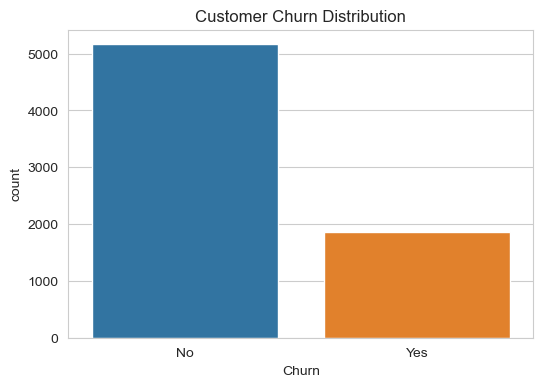

In [13]:
# Visualize Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [14]:
# Churn Percentage

churn_rate = df["Churn"].value_counts(normalize=True) * 100

print(churn_rate)


No     73.421502
Yes    26.578498
Name: Churn, dtype: float64


### Insight

The dataset contains significantly more non-churn customers compared to churn customers.

This indicates the presence of **class imbalance** in the dataset.


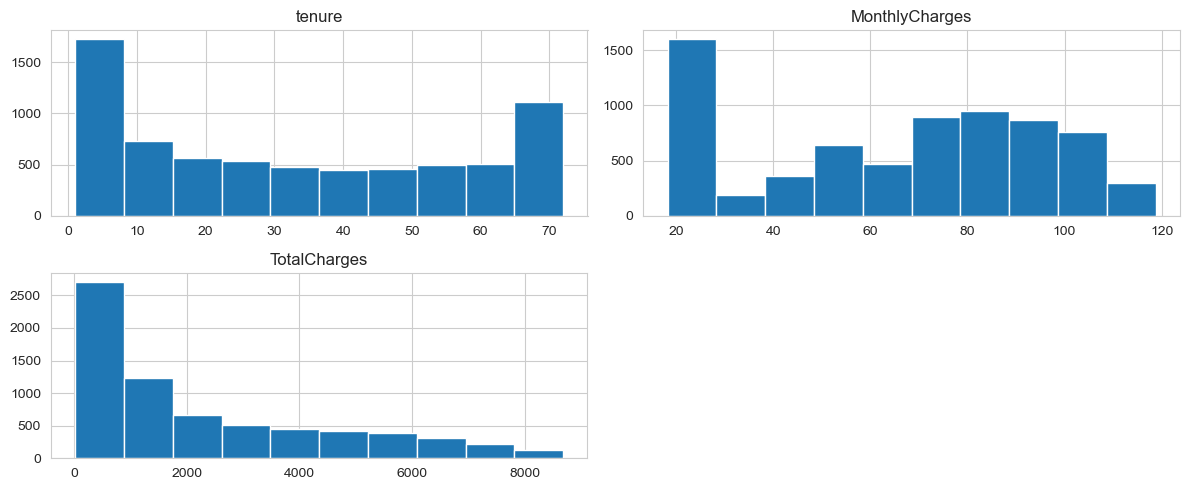

In [15]:
# Numerical Feature Distribution

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[numerical_cols].hist(figsize=(12,5))

plt.tight_layout()

plt.show()

### Insight
1. The tenure distribution is right-skewed. Many customers leave within the initial months, while long-term customers are comparatively fewer but more stable.

2. Customers belong to multiple pricing segments. Pricing strategies may influence customer behavior and churn probability.

3. Customers with long tenure naturally accumulate higher total charges. Long-term customers contribute significantly to overall revenue.

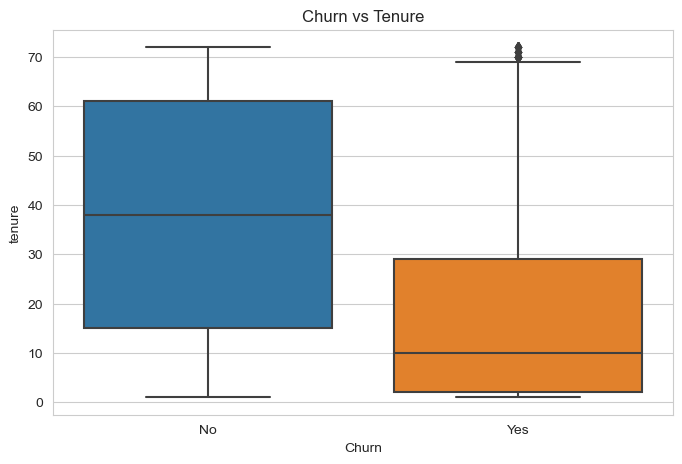

In [16]:
# Churn vs Tenure

plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Churn vs Tenure")

plt.show()

### Insight
Customers who churn generally have lower tenure compared to non-churn customers.
Customers are more likely to churn during the early stages of their relationship with the company.


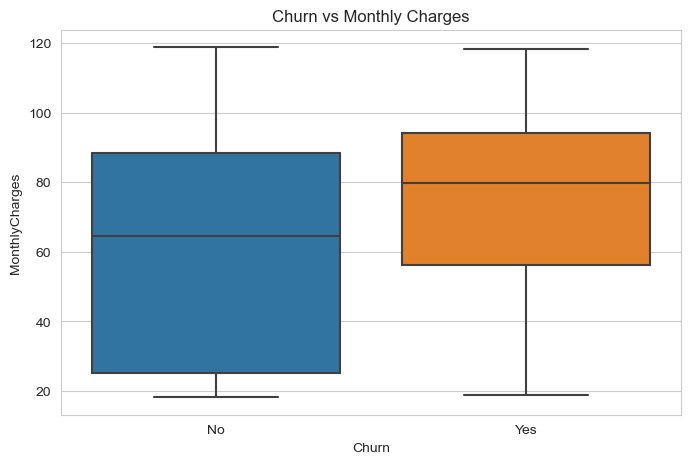

In [17]:
# Churn vs Monthly Charges

plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Churn vs Monthly Charges")

plt.show()

### Insight
Customers with higher monthly charges tend to churn more frequently. Pricing may be an important factor contributing to churn.

---
# Feature Engineering & Target Encoding

In this section, we will:

- Convert target variable into numerical format
- Understand categorical and numerical features
- Prepare data for machine learning models

Machine learning algorithms require numerical input, therefore categorical values must be encoded before modeling.

In [18]:
# Check Target Variable Unique Values

df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [19]:
# Encode target variable
df["Churn"]= df["Churn"].map({'No': 0, "Yes":1})

In [20]:
df["Churn"].value_counts()

0    5163
1    1869
Name: Churn, dtype: int64

In [21]:
# Feature Matrix and Target Variable
X= df.drop("Churn", axis=1)
y=df["Churn"]

In [22]:
# Separate Numerical and Categorical Columns
cat_cols = X.select_dtypes(include='object').columns
num_cols=X.select_dtypes(exclude="object").columns
print("**Category Columns**:: \n",cat_cols)
print("\n**Numerical Columns**::\n", num_cols)

**Category Columns**:: 
 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

**Numerical Columns**::
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


---
# Train-Test Split & Preprocessing Pipeline

In this section, we will:

- Split data into training and testing sets
- Build preprocessing pipelines
- Apply scaling to numerical features
- Apply encoding to categorical features
- Combine preprocessing using ColumnTransformer
- Create a complete machine learning pipeline

This approach helps:
- prevent data leakage
- maintain clean workflow
- improve reproducibility
- simplify deployment

In [23]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5625, 19)
X_test shape: (1407, 19)


In [24]:
# Import Preprocessing Tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [25]:
# Numerical Preprocessing Pipeline
num_pipeline = Pipeline([ ("scaler", StandardScaler()) ])

In [26]:
# Categorical preprocessing pipeline
# drop='first' is used to reduce multicollinearity
cat_pipeline = Pipeline( [ ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore") )])

In [27]:
# Combine Pipelines Using ColumnTransformer
preprocessor = ColumnTransformer([

    ('num', num_pipeline, num_cols),
    
    ('cat', cat_pipeline, cat_cols)
])

In [28]:
# Apply Preprocessing
# Fit preprocessing only on training data to avoid data leakage
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

## Preprocessing Summary

- Numerical features were scaled using **StandardScaler**
- Categorical features were encoded using **OneHotEncoder**
- ColumnTransformer was used to apply separate preprocessing workflows
- Preprocessing was fitted only on training data to prevent data leakage
- **drop='first'** was used to reduce multicollinearity

---
# Logistic Regression Model

In this section, we will:

- Train a Logistic Regression model
- Generate predictions
- Evaluate model performance
- Analyze classification metrics

Logistic Regression is commonly used for binary classification problems and serves as a strong baseline model.

In [29]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

In [30]:
# Create Logistic Regression Model
log_model= LogisticRegression(random_state=42)

In [31]:
# Train Model
log_model.fit(X_train_processed, y_train)

LogisticRegression(random_state=42)

In [32]:
# Make Predictions
y_pred = log_model.predict(X_test_processed)

In [33]:
# Prediction Probabilities
y_prob = log_model.predict_proba(X_test_processed)

In [34]:
# View Sample Prediction Probabilities
print(y_prob[:5])

[[0.9819891  0.0180109 ]
 [0.40834555 0.59165445]
 [0.99508523 0.00491477]
 [0.79912197 0.20087803]
 [0.89654219 0.10345781]]


# Logistic Regression Insights

## 1. Logistic Regression for Binary Classification

Logistic Regression was selected as the baseline model because:
- it performs well on binary classification tasks
- it is computationally efficient
- model predictions are interpretable

---

## 2. Model Training

The model was trained using:
- preprocessed training features
- corresponding churn labels

The training process allows the model to learn relationships between customer attributes and churn behavior.

---

## 3. Probability-Based Prediction

Unlike simple classification outputs, Logistic Regression also provides prediction probabilities.

### Business Importance

Probability scores help businesses:
- identify high-risk customers
- prioritize retention campaigns
- make risk-based decisions

Example:
- 90% churn probability → highly risky customer
- 55% churn probability → moderate risk customer

---

## 4. Sigmoid Function

Logistic Regression uses the sigmoid function to convert linear outputs into probability values between 0 and 1.

This makes the model suitable for binary classification problems such as customer churn prediction.

---
# Model Evaluation

In this section, we will evaluate model performance using:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-Score
- ROC-AUC Score

Evaluation metrics help measure how effectively the model predicts customer churn.

In [35]:
# Import Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [36]:
# accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.3f}")

Accuracy Score: 0.805


In [37]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[918 115]
 [160 214]]


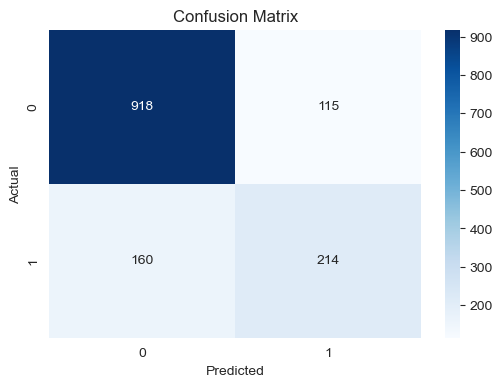

In [38]:
# Visualize Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [39]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [40]:
# ROC-AUC Score

roc_auc = roc_auc_score(y_test, y_prob[:,1])

print(f"ROC-AUC Score: {roc_auc:.3f}")

ROC-AUC Score: 0.836


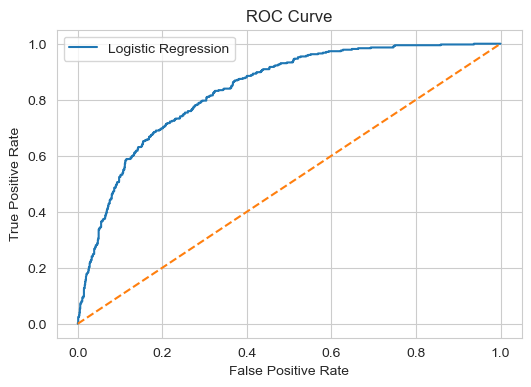

In [41]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1])

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='Logistic Regression')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("images/roc_curve.png", bbox_inches='tight')

plt.show()

## Confusion Matrix Insights

The confusion matrix provides a detailed breakdown of model predictions for churn and non-churn customers.

- The model correctly identified 918 non-churn customers (True Negatives).
- The model correctly identified 214 churn customers (True Positives).
- 115 customers were incorrectly predicted as churners (False Positives).
- 160 actual churn customers were missed by the model (False Negatives).

### Business Interpretation

The model performs well in identifying non-churn customers but still misses a notable number of actual churners.

Since false negatives represent customers who churned without being identified, improving recall would help the business better target high-risk customers and reduce customer attrition.

## ROC-AUC Insights

The Logistic Regression model achieved a ROC-AUC score of approximately 0.84, indicating good class separation capability between churn and non-churn customers.

The ROC curve remains significantly above the random baseline, showing that the model can effectively distinguish high-risk churn customers from stable customers across multiple classification thresholds.

### Business Interpretation

A strong ROC-AUC score suggests the model can be effectively used for:
- customer risk scoring
- churn prioritization
- targeted retention campaigns
- proactive customer engagement

---
# Feature Importance & Model Interpretation

In this section, we will analyze which features contribute most strongly toward customer churn prediction.

Understanding feature importance helps businesses:
- identify major churn drivers
- improve customer retention strategies
- make data-driven business decisions

In [42]:
# Extract Feature Names
encoded_cat_cols = preprocessor.named_transformers_['cat']\
    .named_steps['encoder']\
    .get_feature_names_out(cat_cols)

feature_names = np.concatenate([num_cols, encoded_cat_cols])

In [43]:
feature_names

array(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype=object)

In [44]:
# Extract Logistic Regression Coefficients
coefficients = log_model.coef_[0]

In [45]:
# Create Feature Importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})



In [46]:
# Sort Features by Importance
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,1.122759
3,TotalCharges,0.641497
28,PaymentMethod_Electronic check,0.383578
21,StreamingTV_Yes,0.376957
9,MultipleLines_Yes,0.366169
23,StreamingMovies_Yes,0.349016
26,PaperlessBilling_Yes,0.292275
8,MultipleLines_No phone service,0.172747
17,DeviceProtection_Yes,0.076059
29,PaymentMethod_Mailed check,0.075432


In [47]:
# Top Positive Features

top_positive = feature_importance.head(10)

top_positive

,Feature,Coefficient
10,InternetService_Fiber optic,1.122759
3,TotalCharges,0.641497
28,PaymentMethod_Electronic check,0.383578
21,StreamingTV_Yes,0.376957
9,MultipleLines_Yes,0.366169
23,StreamingMovies_Yes,0.349016
26,PaperlessBilling_Yes,0.292275
8,MultipleLines_No phone service,0.172747
17,DeviceProtection_Yes,0.076059
29,PaymentMethod_Mailed check,0.075432


In [48]:
# Top Negative Features

top_negative = feature_importance.tail(10)

top_negative

,Feature,Coefficient
14,OnlineBackup_No internet service,-0.167637
20,StreamingTV_No internet service,-0.167637
7,PhoneService_Yes,-0.168657
6,Dependents_Yes,-0.230827
19,TechSupport_Yes,-0.329143
13,OnlineSecurity_Yes,-0.370307
2,MonthlyCharges,-0.447631
24,Contract_One year,-0.748433
1,tenure,-1.354386
25,Contract_Two year,-1.361461


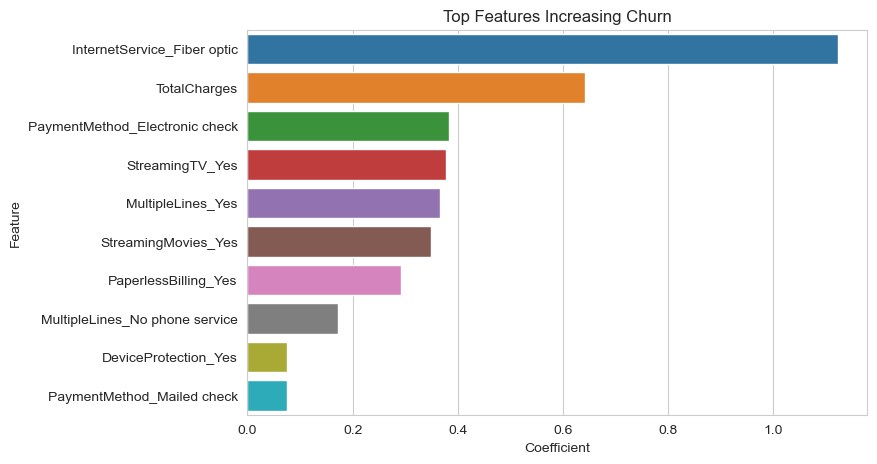

In [49]:
# Visualize Top Positive Features
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Increasing Churn")

plt.show()

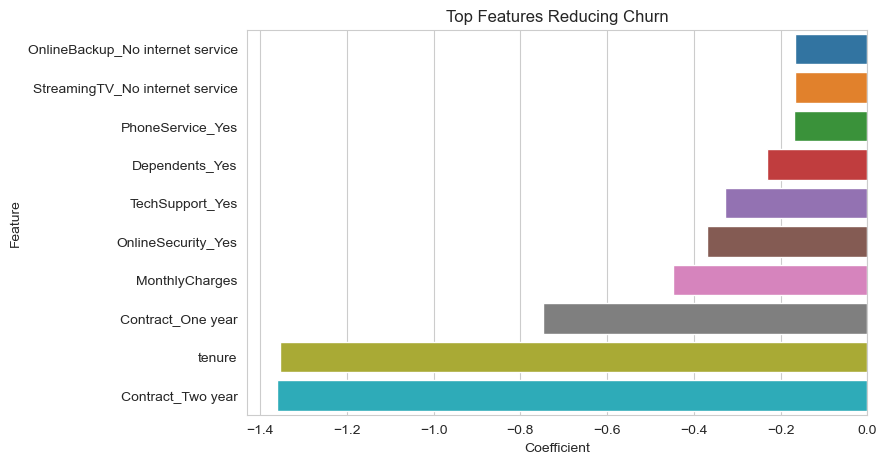

In [50]:
# Visualize Top Negative Features
plt.figure(figsize=(8,5))

sns.barplot( data= top_negative, 
               x= "Coefficient",
               y= "Feature"
           )

plt.title("Top Features Reducing Churn")

plt.show()

# Feature Importance Insights

Logistic Regression coefficients were analyzed to identify the strongest drivers of customer churn.

## Top Features Increasing Churn

The following features showed strong positive coefficients, indicating higher churn probability:

- Fiber optic internet service
- Higher total charges
- Electronic check payment method
- Streaming TV and movie services

### Business Interpretation

Customers using fiber optic internet and electronic payment methods appear more likely to churn. Higher-paying customers may also have increased service expectations, making retention more challenging.

---

## Top Features Reducing Churn

The following features showed strong negative coefficients, indicating lower churn probability:

- Two-year contracts
- Longer customer tenure
- One-year contracts
- Online security services
- Tech support services

### Business Interpretation

Long-term contracts and longer tenure strongly improve customer retention. Customers subscribed to security and support-related services appear more loyal and less likely to churn.

---

## Overall Insight

The analysis suggests that customer loyalty, long-term commitment, and value-added support services play a major role in reducing churn risk.

---
# Handling Imbalanced Data

Customer churn datasets are often imbalanced because the number of non-churn customers is significantly higher than churn customers.

This imbalance may cause the model to favor the majority class and miss actual churners.

To address this issue, we will use:
```python
class_weight='balanced'
```

This gives higher importance to minority churn customers during model training.

In [51]:
# Logistic Regression with Balanced Classes

balanced_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

In [52]:
# Train Balanced Model
balanced_model.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [53]:
# Make Predictions

balanced_pred = balanced_model.predict(X_test_processed)

balanced_prob = balanced_model.predict_proba(X_test_processed)

In [54]:
# Classification Report

print(classification_report(y_test, balanced_pred))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [55]:
# Confusion Matrix

balanced_cm = confusion_matrix(y_test, balanced_pred)

print(balanced_cm)

[[725 308]
 [ 77 297]]


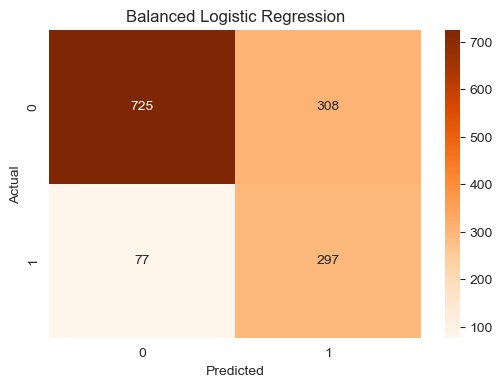

In [56]:
# Visualize Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    balanced_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Balanced Logistic Regression")

plt.show()

In [57]:
# ROC-AUC Score

balanced_auc = roc_auc_score(
    y_test,
    balanced_prob[:,1]
)

print("Balanced ROC-AUC:", balanced_auc)

Balanced ROC-AUC: 0.835377722328921


In [58]:
# Compare Old vs Balanced Model

comparison = pd.DataFrame({

    'Model': ['Original Logistic', 'Balanced Logistic'],

    'ROC-AUC': [
        roc_auc,
        balanced_auc
    ]
})

comparison

,Model,ROC-AUC
0,Original Logistic,0.836064
1,Balanced Logistic,0.835378


# Balanced Logistic Regression Insights

Applying `class_weight='balanced'` significantly improved the model's ability to identify churn customers.

## Key Improvements

- Churn recall increased from approximately 57% to 79%
- False negatives reduced substantially
- The model became more effective at detecting high-risk churn customers

---

## Tradeoff Observed

The improved recall also increased false positives, meaning more non-churn customers were incorrectly predicted as churners.

As a result:
- precision decreased
- overall accuracy slightly reduced

---

## Business Interpretation

For customer churn prediction, improving recall is often more valuable than maximizing accuracy because missing actual churn customers may directly impact revenue and customer retention.

The balanced model therefore provides a more business-oriented churn prediction approach by prioritizing churn detection over overall accuracy.

---
# Random Forest Classifier

In this section, we will train a Random Forest model to improve churn prediction performance.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to produce more robust and accurate predictions.

Compared to Logistic Regression, Random Forest can:
- capture non-linear relationships
- handle complex feature interactions
- improve predictive performance

In [59]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

In [60]:
# Create Random Forest Model

rf_model= RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
)

In [61]:
# Train Random Forest
rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [62]:
# Prediction

rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)

In [63]:
# Classification 

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.75      0.64       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.74      1407
weighted avg       0.80      0.77      0.78      1407



In [64]:
# Confusion Matrix

rf_cm = confusion_matrix(y_test, rf_pred)
print(rf_cm)

[[808 225]
 [ 95 279]]


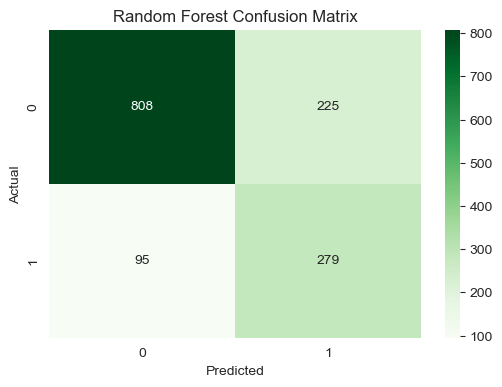

In [65]:
# Visualize Confusion Matrix

plt.figure(figsize=(6,4))
sns.heatmap(data= rf_cm, annot=True, fmt='d', cmap='Greens' )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.savefig("images/random_forest_confusion_matrix.png", bbox_inches='tight')
plt.show()

In [66]:
#  ROC-AUC Score

rf_auc = roc_auc_score(y_test, rf_prob[:,1])
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.836001521967583


In [67]:
# Random Forest feature importance

rf_importance = pd.DataFrame({
    
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values( by= 'Importance', ascending= False )

rf_importance.head()

,Feature,Importance
1,tenure,0.173002
3,TotalCharges,0.144455
2,MonthlyCharges,0.107390
25,Contract_Two year,0.100932
10,InternetService_Fiber optic,0.062288


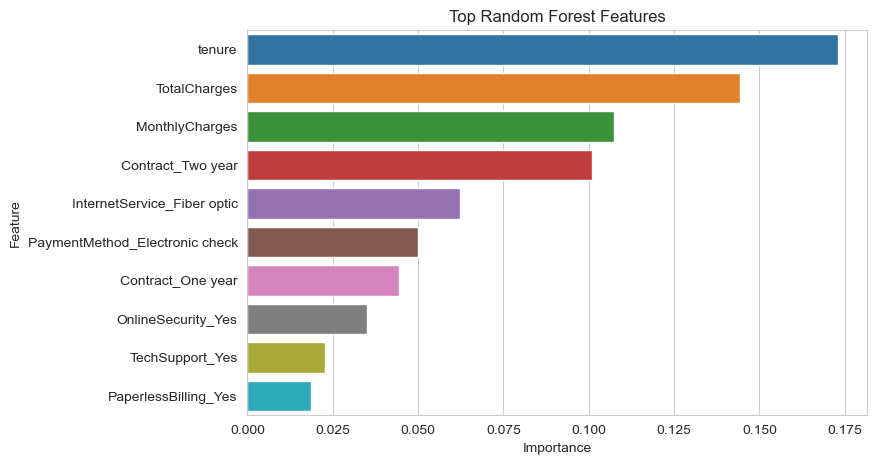

In [68]:
# Visualize top importance Features

top_rf = rf_importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot( data=top_rf, x='Importance', y='Feature')

plt.title('Top Random Forest Features')

plt.savefig("images/random_forest_feature_importance.png", bbox_inches='tight')

plt.show()

In [69]:
# Model Comparison

comparison = pd.DataFrame({

    'Model': [
        'Original Logistic',
        'Balanced Logistic',
        'Random Forest'
    ],

    'ROC-AUC': [
        roc_auc,
        balanced_auc,
        rf_auc
    ]
})

comparison

,Model,ROC-AUC
0,Original Logistic,0.836064
1,Balanced Logistic,0.835378
2,Random Forest,0.836002


#### Note:
Similar ROC-AUC scores do not necessarily mean models behave identically. ROC-AUC measures ranking capability across thresholds, while precision, recall, and confusion matrices reflect classification behavior at a specific threshold. Different models may therefore show similar ROC-AUC values but different business tradeoffs.

# Random Forest Insights

The Random Forest model demonstrated strong overall performance for customer churn prediction.

## Model Performance

- Accuracy improved compared to the balanced Logistic Regression model
- Churn recall remained strong at approximately 75%
- ROC-AUC score remained high at approximately 0.84

The model achieved a better balance between:
- churn detection
- false positive control
- overall classification performance

---

## Key Feature Importance

The most influential features identified by the Random Forest model were:

- Customer tenure
- Total charges
- Monthly charges
- Two-year contract type
- Fiber optic internet service

These features contributed most strongly toward churn prediction decisions.

---

## Business Interpretation

The analysis suggests that:
- long-term customers are less likely to churn
- pricing and billing patterns strongly influence churn behavior
- contract stability plays a major role in customer retention
- internet service type impacts customer satisfaction and retention risk

---

## Overall Conclusion

Compared to Logistic Regression, Random Forest captured customer churn patterns more effectively by learning complex non-linear relationships between customer attributes.

This model provides a strong foundation for proactive churn prediction and customer retention strategies.

In [70]:
# Final Model Selected

print("Final Selected Model: Random Forest Classifier")

Final Selected Model: Random Forest Classifier


---
---
# Executive Summary

This project focused on predicting customer churn using machine learning techniques on a telecom customer dataset.

The workflow included:
- data cleaning
- exploratory data analysis (EDA)
- preprocessing and feature engineering
- model training and evaluation
- handling class imbalance
- model comparison and interpretation

Multiple machine learning models were evaluated, including:
- Logistic Regression
- Balanced Logistic Regression
- Random Forest Classifier

---

# Key Findings

## 1. Customer Retention Drivers

The analysis identified several important factors associated with customer churn:

### Features Increasing Churn Risk
- Fiber optic internet service
- High monthly and total charges
- Electronic check payment method
- Month-to-month contract behavior

### Features Reducing Churn Risk
- Longer customer tenure
- One-year and two-year contracts
- Online security services
- Tech support services

---

## 2. Model Performance

### Logistic Regression
Provided a strong baseline model with good interpretability and balanced performance.

### Balanced Logistic Regression
Improved churn recall significantly by prioritizing minority churn customers, though at the cost of increased false positives.

### Random Forest Classifier
Delivered the best overall balance between:
- recall
- precision
- accuracy
- churn detection capability

The Random Forest model also captured more complex customer behavior patterns.

---

# Business Recommendations

Based on the analysis, telecom companies may improve customer retention by:

- Encouraging long-term customer contracts
- Improving customer support services
- Monitoring high-charge customers more closely
- Identifying high-risk customers proactively
- Designing targeted retention campaigns for vulnerable customer segments

---

# Deployment Consideration

The `customerID` column was excluded from model training because it does not contain predictive information.

In production environments, customer identifiers are typically stored separately and later combined with prediction outputs to identify high-risk customers for retention actions.

---

# Overall Conclusion

This project demonstrates how machine learning can help businesses proactively identify potential churn customers and support data-driven retention strategies.

The workflow also highlights the importance of:
- proper preprocessing
- avoiding data leakage
- handling class imbalance
- evaluating business tradeoffs
- interpreting model outputs

---
---
# Final Conclusion

This project successfully developed and evaluated multiple machine learning models for customer churn prediction.

Among the evaluated models, the Random Forest Classifier provided the best overall balance between:
- recall
- precision
- accuracy
- churn detection capability

The analysis highlighted that:
- long-term contracts reduce churn risk
- customer tenure strongly impacts retention
- pricing and internet service type influence churn behavior

The project also demonstrated the importance of:
- proper preprocessing
- avoiding data leakage
- handling class imbalance
- evaluating business tradeoffs

Overall, machine learning can help telecom businesses proactively identify high-risk customers and improve customer retention strategies through data-driven decision-making.